In [1]:
!pip install yfinance
!pip install scikit-learn
!pip install tensorflow
!pip install matplotlib
!pip install seaborn
!pip install pandas
!pip install numpy

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Dropout

#Random Forest

In [4]:
df = pd.read_csv('/content/drive/MyDrive/karthik/VK/Financial-Time-Series-Analytics/Data/all_bank_stock_data.csv')

In [5]:
print(df.head())

         Date    Bank               Open               High  \
0         NaN     NaN             LLOY.L             LLOY.L   
1  2015-01-02  Lloyds  76.11351372005572  76.39220720232863   
2  2015-01-05  Lloyds  75.71538565801829  76.04384912596093   
3  2015-01-06  Lloyds  74.28209387862202  74.70014173189884   
4  2015-01-07  Lloyds    72.978191980182  73.59828873371622   

                 Low              Close     Volume  
0             LLOY.L             LLOY.L     LLOY.L  
1  75.31624532740311  75.79500579833984   54277932  
2  74.11289035617187  74.27214813232422  102525515  
3  72.53030395507812  72.53030395507812  133810250  
4   72.5302928555775  72.66963958740234  108980419  


In [6]:
numeric_cols = ['Open', 'High', 'Low', 'Close', 'Volume']

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

In [7]:
df = df.dropna()

In [8]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df['Bank'] = le.fit_transform(df['Bank'])

In [9]:
df['Date'] = pd.to_datetime(df['Date'])

df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Day'] = df['Date'].dt.day

df = df.drop(columns=['Date'])

In [10]:
X = df[['Bank', 'Year', 'Month', 'Day', 'Open', 'High', 'Low', 'Volume']]

y = df['Close']

In [11]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    shuffle=False,
    random_state=42
)

## Hyperparameter Tuning (Random Forest)

In [12]:
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV

# TimeSeriesSplit instead of default KFold — regular CV would shuffle rows and let
# the model validate on data that comes BEFORE some of its training data (leakage).
rf_param_dist = {
    "n_estimators": [100, 200, 300, 400, 500],
    "max_depth": [None, 5, 10, 15, 20],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2", 1.0],
}

rf_tscv = TimeSeriesSplit(n_splits=5)

rf_search = RandomizedSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_distributions=rf_param_dist,
    n_iter=20,
    scoring="neg_mean_absolute_error",
    cv=rf_tscv,
    random_state=42,
    n_jobs=-1,
)

rf_search.fit(X_train, y_train)

print("Best Random Forest params:", rf_search.best_params_)
print("Best CV MAE:", -rf_search.best_score_)

Best Random Forest params: {'n_estimators': 100, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 1.0, 'max_depth': None}
Best CV MAE: 20.207858958866282


In [16]:
rf = rf_search.best_estimator_

rf.fit(X_train, y_train)

pred = rf.predict(X_test)

In [17]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, pred)
rmse = np.sqrt(mean_squared_error(y_test, pred))
r2 = r2_score(y_test, pred)

print("Mean Absolute Error :", mae)
print("Root Mean Squared Error :", rmse)
print("R² Score :", r2)

Mean Absolute Error : 54.93492915868483
Root Mean Squared Error : 131.34915284042253
R² Score : 0.5992923222736499


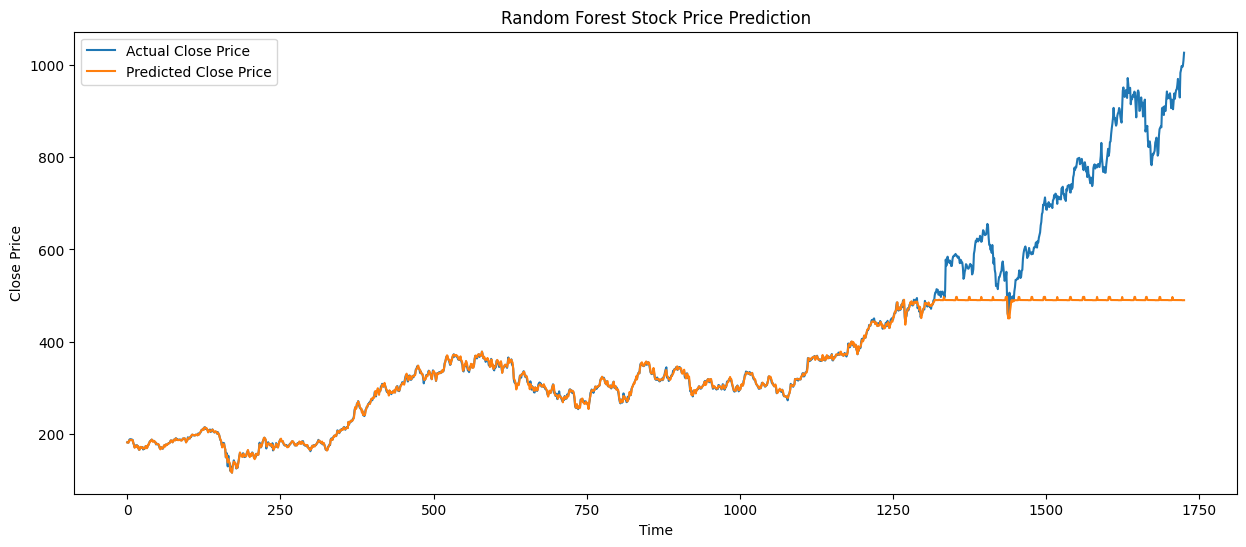

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,6))

plt.plot(y_test.values, label='Actual Close Price')
plt.plot(pred, label='Predicted Close Price')

plt.title('Random Forest Stock Price Prediction')
plt.xlabel('Time')
plt.ylabel('Close Price')
plt.legend()

plt.show()

In [19]:
importance = rf.feature_importances_

for feature, score in zip(X.columns, importance):
    print(f"{feature}: {score:.4f}")

Bank: 0.0000
Year: 0.0000
Month: 0.0000
Day: 0.0000
Open: 0.1499
High: 0.3945
Low: 0.4555
Volume: 0.0000


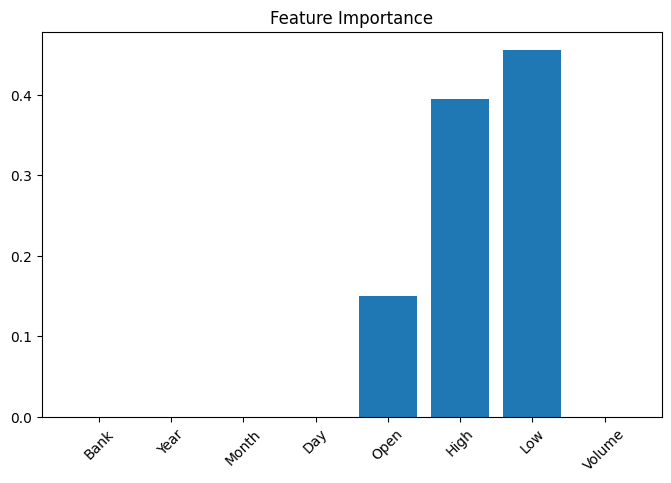

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.bar(X.columns, importance)
plt.title("Feature Importance")
plt.xticks(rotation=45)
plt.show()

In [21]:
import joblib

joblib.dump(rf, "random_forest_stock_model.pkl")

['random_forest_stock_model.pkl']

In [22]:
from google.colab import files
files.download("random_forest_stock_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

In [24]:
df = pd.read_csv('/content/drive/MyDrive/karthik/VK/Financial-Time-Series-Analytics/Data/all_bank_stock_data.csv')

In [25]:
df['Date'] = pd.to_datetime(df['Date'])

In [26]:
le = LabelEncoder()
df['Bank'] = le.fit_transform(df['Bank'])

In [27]:
cols = ['Open','High','Low','Close','Volume']

for c in cols:
    df[c] = pd.to_numeric(df[c], errors='coerce')

df = df.dropna()

In [28]:
df = df.sort_values('Date')

In [29]:
# Fit one scaler PER BANK — mixing Lloyds (~£0.50), Barclays (~£2), and Goldman
# Sachs (~$300) into a single MinMaxScaler would distort all three price scales.
bank_scalers = {}
bank_scaled_close = {}

for bank_id in sorted(df['Bank'].unique()):
    bank_close = df.loc[df['Bank'] == bank_id].sort_values('Date')[['Close']]

    scaler = MinMaxScaler(feature_range=(0, 1))
    bank_scaled_close[bank_id] = scaler.fit_transform(bank_close)
    bank_scalers[bank_id] = scaler

In [30]:
sequence_length = 60

bank_sequences = {}  # bank_id -> (X_bank, y_bank)

for bank_id, scaled_close in bank_scaled_close.items():
    X_bank, y_bank = [], []

    for i in range(sequence_length, len(scaled_close)):
        X_bank.append(scaled_close[i-sequence_length:i, 0])
        y_bank.append(scaled_close[i, 0])

    bank_sequences[bank_id] = (np.array(X_bank), np.array(y_bank))

In [31]:
X_train_parts, X_test_parts = [], []
y_train_parts, y_test_parts = [], []
test_bank_ids = []  # remembers which bank each TEST row belongs to, for inverse-scaling later

for bank_id, (X_bank, y_bank) in bank_sequences.items():
    split = int(len(X_bank) * 0.8)

    X_train_parts.append(X_bank[:split])
    X_test_parts.append(X_bank[split:])

    y_train_parts.append(y_bank[:split])
    y_test_parts.append(y_bank[split:])

    test_bank_ids.extend([bank_id] * (len(X_bank) - split))

X_train = np.concatenate(X_train_parts).reshape(-1, sequence_length, 1)
X_test = np.concatenate(X_test_parts).reshape(-1, sequence_length, 1)

y_train = np.concatenate(y_train_parts)
y_test = np.concatenate(y_test_parts)

test_bank_ids = np.array(test_bank_ids)

In [32]:
print(X_train.shape, X_test.shape)
print(y_train.shape, y_test.shape)

(6758, 60, 1) (1691, 60, 1)
(6758,) (1691,)


#LSTM

## Hyperparameter Tuning (LSTM)

In [33]:
from tensorflow.keras.optimizers import Adam

# Hold out the LAST 15% of the training sequences as a validation set for tuning,
# so X_test stays completely unseen until the final chosen model is evaluated.
val_split = int(len(X_train) * 0.85)

X_tr, X_val = X_train[:val_split], X_train[val_split:]
y_tr, y_val = y_train[:val_split], y_train[val_split:]

lstm_configs = [
    {"units": 32,  "dropout": 0.2, "batch_size": 32, "learning_rate": 0.001},
    {"units": 64,  "dropout": 0.2, "batch_size": 32, "learning_rate": 0.001},
    {"units": 64,  "dropout": 0.3, "batch_size": 16, "learning_rate": 0.0005},
    {"units": 100, "dropout": 0.2, "batch_size": 32, "learning_rate": 0.001},
]

def build_lstm(units, dropout, learning_rate):
    m = Sequential()
    m.add(LSTM(units, return_sequences=True, input_shape=(sequence_length, 1)))
    m.add(Dropout(dropout))
    m.add(LSTM(units))
    m.add(Dropout(dropout))
    m.add(Dense(1))
    m.compile(optimizer=Adam(learning_rate=learning_rate), loss="mse")
    return m

lstm_tuning_results = []

for cfg in lstm_configs:
    tuning_model = build_lstm(cfg["units"], cfg["dropout"], cfg["learning_rate"])

    tuning_history = tuning_model.fit(
        X_tr, y_tr,
        epochs=15,
        batch_size=cfg["batch_size"],
        validation_data=(X_val, y_val),
        verbose=0,
    )

    val_loss = min(tuning_history.history["val_loss"])
    lstm_tuning_results.append({**cfg, "val_loss": val_loss})
    print(cfg, "-> val_loss:", val_loss)

lstm_tuning_df = pd.DataFrame(lstm_tuning_results).sort_values("val_loss").reset_index(drop=True)
lstm_tuning_df

{'units': 32, 'dropout': 0.2, 'batch_size': 32, 'learning_rate': 0.001} -> val_loss: 0.00028633681358769536
{'units': 64, 'dropout': 0.2, 'batch_size': 32, 'learning_rate': 0.001} -> val_loss: 0.00020969973411411047
{'units': 64, 'dropout': 0.3, 'batch_size': 16, 'learning_rate': 0.0005} -> val_loss: 0.00022313286899589002
{'units': 100, 'dropout': 0.2, 'batch_size': 32, 'learning_rate': 0.001} -> val_loss: 0.00018920544243883342


,units,dropout,batch_size,learning_rate,val_loss
0,100,0.2,32,0.0010,0.000189
1,64,0.2,32,0.0010,0.000210
2,64,0.3,16,0.0005,0.000223
3,32,0.2,32,0.0010,0.000286


In [34]:
best_lstm_config = lstm_tuning_df.iloc[0].to_dict()
print("Best LSTM config:", best_lstm_config)

model = build_lstm(
    int(best_lstm_config["units"]),
    best_lstm_config["dropout"],
    best_lstm_config["learning_rate"],
)

model.summary()

Best LSTM config: {'units': 100.0, 'dropout': 0.2, 'batch_size': 32.0, 'learning_rate': 0.001, 'val_loss': 0.00018920544243883342}


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_8 (LSTM)                   │ (None, 60, 100)        │        40,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 60, 100)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_9 (LSTM)                   │ (None, 100)            │        80,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │           101 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 121,301 (473.83 KB)

 Trainable params: 121,301 (473.83 KB)

 Non-trainable params: 0 (0.00 B)

In [35]:
history = model.fit(
    X_train,
    y_train,
    epochs=30,
    batch_size=int(best_lstm_config["batch_size"]),
    validation_data=(X_test, y_test),
    verbose=1
)

Epoch 1/30
212/212 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - loss: 0.0019 - val_loss: 0.0018
Epoch 2/30
212/212 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 6.2801e-04 - val_loss: 7.7199e-04
Epoch 3/30
212/212 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 5.1927e-04 - val_loss: 6.0822e-04
Epoch 4/30
212/212 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 4.9412e-04 - val_loss: 5.6753e-04
Epoch 5/30
212/212 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 4.9513e-04 - val_loss: 6.2269e-04
Epoch 6/30
212/212 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 4.0861e-04 - val_loss: 4.6655e-04
Epoch 7/30
212/212 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 3.8769e-04 - val_loss: 4.6939e-04
Epoch 8/30
212/212 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 3.6225e-04 - val_loss: 8.0747e-04
Epoch 9/30
212/212 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 3.1836e-04 - val_loss: 3.6496e-04
Epoch 10/30
212/212 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 3.0619e-04 - val_loss: 3.4063e-04
Epoch 11/30
212/212 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - l

In [37]:
pred_scaled = model.predict(X_test)

pred_parts, actual_parts = [], []

for bank_id in sorted(set(test_bank_ids)):
    mask = test_bank_ids == bank_id
    bank_scaler = bank_scalers[bank_id]

    pred_parts.append(bank_scaler.inverse_transform(pred_scaled[mask]))
    actual_parts.append(bank_scaler.inverse_transform(y_test[mask].reshape(-1, 1)))

pred = np.concatenate(pred_parts)
actual = np.concatenate(actual_parts)

53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step


In [38]:
mae = mean_absolute_error(actual,pred)

rmse = np.sqrt(mean_squared_error(actual,pred))

r2 = r2_score(actual,pred)

print("MAE :",mae)
print("RMSE:",rmse)
print("R2 :",r2)

MAE : 5.463023230283659
RMSE: 9.052297759262254
R2 : 0.9987846032199081


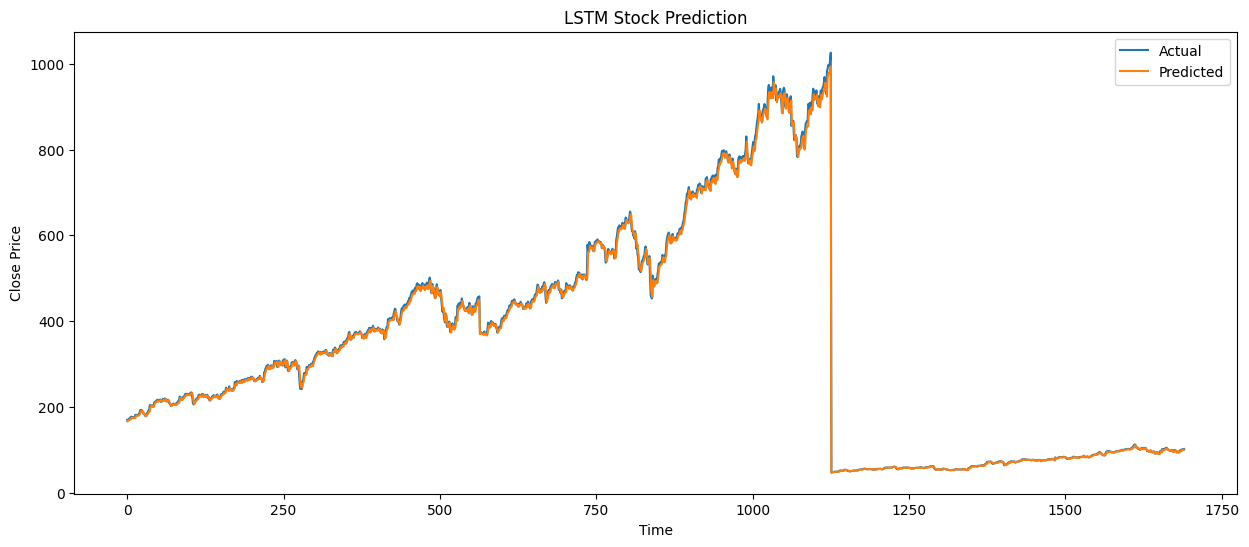

In [39]:
plt.figure(figsize=(15,6))

plt.plot(actual,label='Actual')

plt.plot(pred,label='Predicted')

plt.title("LSTM Stock Prediction")

plt.xlabel("Time")

plt.ylabel("Close Price")

plt.legend()

plt.show()

In [40]:
model.save("LSTM_stock_model.keras")

In [41]:
from google.colab import files

files.download("LSTM_stock_model.keras")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>